#Project : Student Performance

ML WORKFLOW :

✅ Data preprocessing

✅ Data analysis (EDA)

✅ Multiple model training

✅ Model comparison

✅ Best model selection

✅ Hyperparameter tuning on the best model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score , confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#1-Data Understanding

In [ ]:
import pandas as pd

df = pd.read_csv("/content/student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


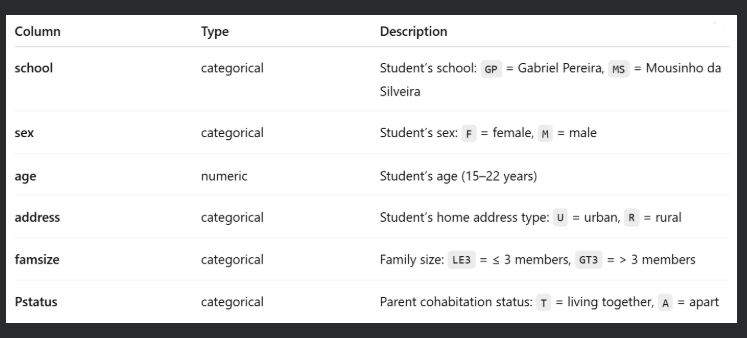

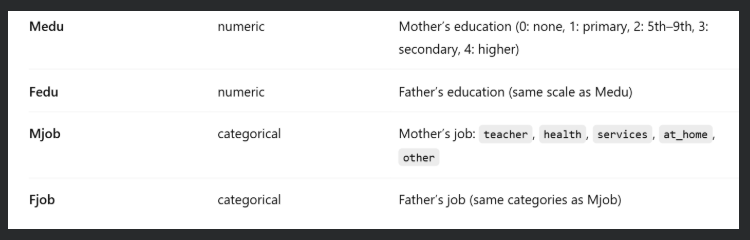

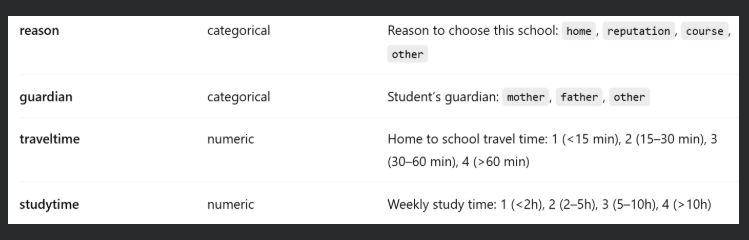

Get the first five rows


In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


retuen information about table like number of rows

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

Statical information about numerical columns

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


What I get from reading the data ?

✔ Mix of categorical + numerical

✔ No missing values

#Target

TARGET (PASS / FAIL)

Final grade G3:

Pass → G3 >= 10

Fail → G3 < 10

In [ ]:
# data generation
df["pass"] = (df["G3"] >= 10).astype(int)
df.drop(columns=["G1", "G2", "G3"], inplace=True)

In [ ]:
df["pass"]

,pass
0,0
1,0
2,1
3,1
4,1
...,...
390,0
391,1
392,0
393,1


In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,no,no,5,5,4,4,5,4,11,0
391,MS,M,17,U,LE3,T,3,1,services,services,...,yes,no,2,4,5,3,4,2,3,1
392,MS,M,21,R,GT3,T,1,1,other,other,...,no,no,5,5,3,3,3,3,3,0
393,MS,M,18,R,LE3,T,3,2,services,other,...,yes,no,4,4,1,3,4,5,0,1


#Step 2 : EXPLORATORY DATA ANALYSIS (EDA)

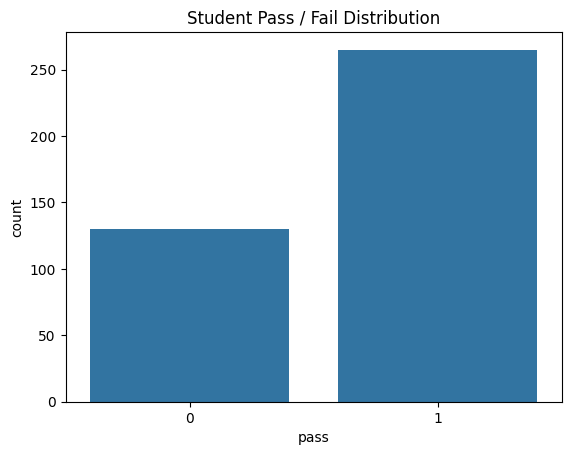

In [ ]:
# count frequency of each value
sns.countplot(x=df["pass"])
plt.title("Student Pass / Fail Distribution")
plt.show()

Corr between features

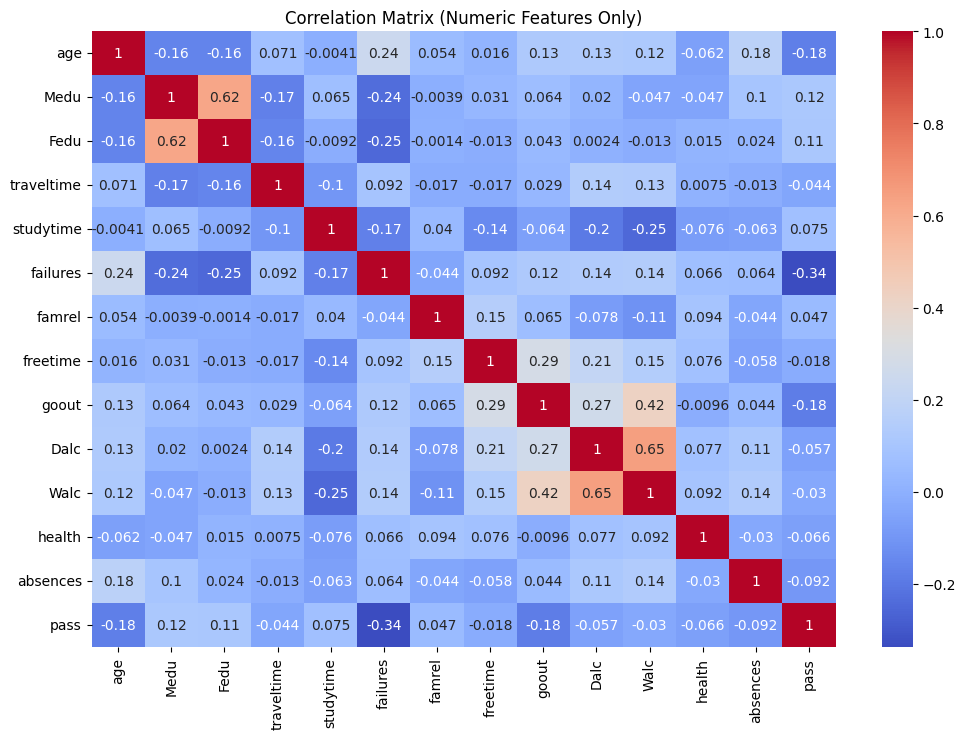

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
# get correlation between features and (each feature and target)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()


#Step 3 : DATA PREPROCESSING

Encode categorical features

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,pass
0,0,0,18,1,0,0,4,4,0,4,...,0,0,4,3,4,1,1,3,6,0
1,0,0,17,1,0,1,1,1,0,2,...,1,0,5,3,3,1,1,3,4,0
2,0,0,15,1,1,1,1,1,0,2,...,1,0,4,3,2,2,3,3,10,1
3,0,0,15,1,0,1,4,2,1,3,...,1,1,3,2,2,1,1,5,2,1
4,0,0,16,1,0,1,3,3,2,2,...,0,0,4,3,2,1,2,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,20,1,1,0,2,2,3,3,...,0,0,5,5,4,4,5,4,11,0
391,1,1,17,1,1,1,3,1,3,3,...,1,0,2,4,5,3,4,2,3,1
392,1,1,21,0,0,1,1,1,2,2,...,0,0,5,5,3,3,3,3,3,0
393,1,1,18,0,1,1,3,2,3,2,...,1,0,4,4,1,3,4,5,0,1


Corr between features & target

In [ ]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()["pass"].sort_values(ascending=False)

print(corr)

pass          1.000000
higher        0.157708
Medu          0.115396
Fedu          0.108057
reason        0.099300
paid          0.092665
studytime     0.074613
sex           0.070618
internet      0.061791
address       0.052282
famrel        0.046683
famsize       0.041842
Fjob          0.028309
Mjob          0.026592
activities    0.012414
nursery      -0.008784
freetime     -0.018321
Walc         -0.029957
school       -0.031254
Pstatus      -0.044050
traveltime   -0.044446
Dalc         -0.057343
famsup       -0.059219
health       -0.065668
absences     -0.092244
romantic     -0.097737
schoolsup    -0.099860
guardian     -0.101407
age          -0.179645
goout        -0.183399
failures     -0.337731
Name: pass, dtype: float64


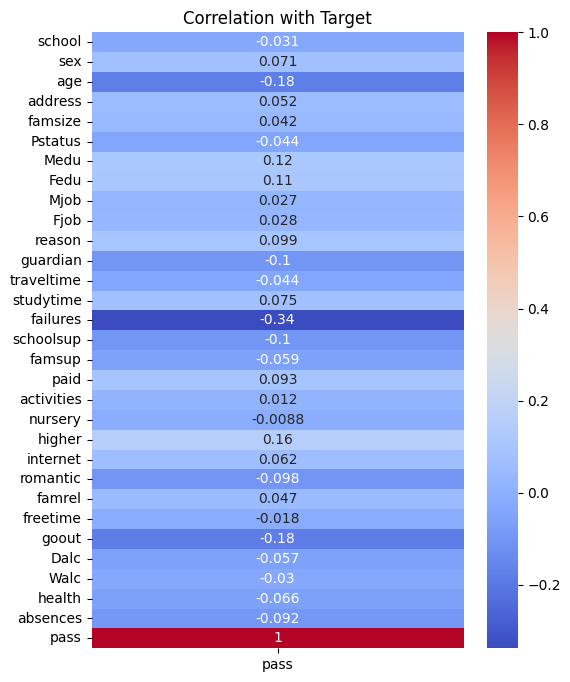

In [ ]:
plt.figure(figsize=(6,8))

sns.heatmap(
    numeric_df.corr()[["pass"]],
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation with Target")
plt.show()

Split features & target

In [ ]:
X = df.drop(columns="pass")
y = df["pass"]

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-0.36971698,  1.01917107, -1.30533216, ..., -1.02116036,
        -0.40850655, -0.68870507],
       [-0.36971698,  1.01917107, -0.52411064, ..., -1.02116036,
         0.31265585,  0.05745768],
       [-0.36971698, -0.98118954, -1.30533216, ..., -0.25649999,
         0.31265585, -0.68870507],
       ...,
       [-0.36971698,  1.01917107,  1.0383324 , ...,  2.03748109,
         1.03381825, -0.19126324],
       [-0.36971698, -0.98118954,  1.0383324 , ..., -1.02116036,
         0.31265585,  1.05234135],
       [ 2.70477161,  1.01917107,  1.81955392, ...,  0.50816037,
        -1.12966895,  0.3061786 ]])

#Step 4 : BUILD MULTIPLE ML MODELS

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf',C=1),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

MODEL TRAINING & EVALUATION

In [ ]:
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

In [ ]:
results = {} # {"KNN=> acc , f1 , pre" , "logis =>acc , f1 , pre" }

for name, model in models.items():# name = "Logistic Regression" , model = LogisticRegression(max_iter=1000)

    if name == "Random Forest":
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    results[name] = evaluate(y_test, preds)


In [ ]:
results

{'Logistic Regression': {'Accuracy': 0.6835443037974683,
  'Precision': 0.7258064516129032,
  'Recall': 0.8490566037735849,
  'F1': 0.782608695652174},
 'SVM': {'Accuracy': 0.6835443037974683,
  'Precision': 0.7058823529411765,
  'Recall': 0.9056603773584906,
  'F1': 0.7933884297520661},
 'KNN': {'Accuracy': 0.6708860759493671,
  'Precision': 0.7076923076923077,
  'Recall': 0.8679245283018868,
  'F1': 0.7796610169491526},
 'Random Forest': {'Accuracy': 0.6708860759493671,
  'Precision': 0.7076923076923077,
  'Recall': 0.8679245283018868,
  'F1': 0.7796610169491526}}

#MODEL COMPARISON

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Logistic Regression,SVM,KNN,Random Forest
Accuracy,0.683544,0.683544,0.670886,0.670886
Precision,0.725806,0.705882,0.707692,0.707692
Recall,0.849057,0.905660,0.867925,0.867925
F1,0.782609,0.793388,0.779661,0.779661


In [ ]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.683544,0.725806,0.849057,0.782609
SVM,0.683544,0.705882,0.905660,0.793388
KNN,0.670886,0.707692,0.867925,0.779661
Random Forest,0.670886,0.707692,0.867925,0.779661


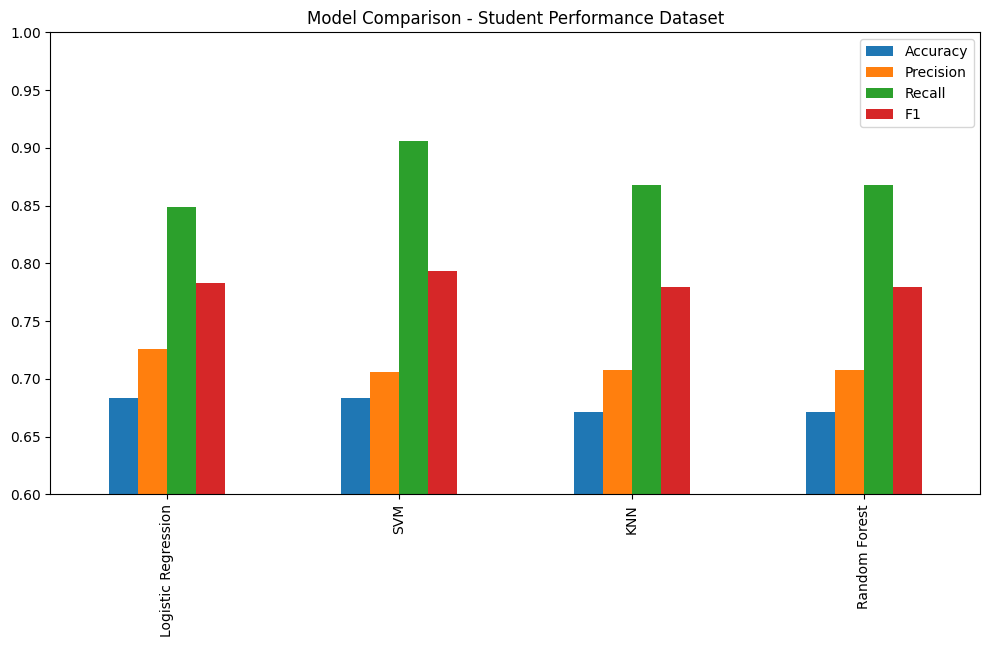

In [ ]:
results_df.plot(kind="bar", figsize=(12,6))
plt.title("Model Comparison - Student Performance Dataset")
plt.ylim(0.6, 1.0)
plt.show()


try to change hyperparameters to get more more accurcy  RANDOM FOREST

In [ ]:
# Hyperparameter in random forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
# using Grid Search to get the best Hyperparameters
rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid ,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
best_rf = grid.best_estimator_

y_pred_final = best_rf.predict(X_test)

final_results = evaluate(y_test, y_pred_final)
final_results

{'Accuracy': 0.6582278481012658,
 'Precision': 0.6805555555555556,
 'Recall': 0.9245283018867925,
 'F1': 0.784}

#try bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier # New
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# Load dataset
df = pd.read_csv("/content/student-mat.csv", sep=";")


df["pass"] = (df["G3"] >= 10).astype(int)
df.drop(columns=["G1", "G2", "G3"], inplace=True)

# Encode categorical features within this cell
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

#split x,y
x=df.drop("pass",axis=1)
y=df['pass']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)
# Base model
Base_model = SVC(probability=True)
# Bagging Classifier
bagging_clf = BaggingClassifier(
    estimator=Base_model,
    n_estimators=100,
    random_state=42,
    n_jobs=-1 #   CPU Cores
)
# Train
bagging_clf.fit(X_train, y_train)
# Predict
y_pred = bagging_clf.predict(X_test)
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6464646464646465


In [ ]:
from sklearn.ensemble import AdaBoostClassifier # New
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# Load dataset
df = pd.read_csv("/content/student-mat.csv", sep=";")


df["pass"] = (df["G3"] >= 10).astype(int)
df.drop(columns=["G1", "G2", "G3"], inplace=True)

# Encode categorical features within this cell
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

#split x,y
x=df.drop("pass",axis=1)
y=df['pass']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)
# Base model
Base_model = DecisionTreeClassifier(max_depth=3, random_state=42)
# Bagging Classifier
bagging_clf = AdaBoostClassifier(
    estimator=Base_model,
    n_estimators=100,
    learning_rate=0.4,
    random_state=42,
)
# Train
bagging_clf.fit(X_train, y_train)
# Predict
y_pred = bagging_clf.predict(X_test)
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6565656565656566
